In [312]:
import pandas as pd
import numpy as np

# Global formatting: display all floats to 4 decimal places.
pd.options.display.float_format = "{:.4f}".format
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv", index_col=0)

df = df.sample(1000, random_state=42)

This dataset contains detailed information about residential properties, including dwelling type, zoning, location, physical characteristics (e.g., lot size, living area, basement and garage features), quality and condition ratings (such as OverallQual and KitchenQual), amenities, and sale details, with selected key features (OverallQual, GrLivArea, GarageArea, TotalBsmtSF, KitchenQual, MiscVal) expected to have a monotonic relationship with the target variable, SalePrice.

detailed description in dataset/data_description.txt

In [313]:
monotonic = [
    "OverallQual",
    "GrLivArea",
    "GarageArea",
    "TotalBsmtSF",
    "KitchenQual",
    #'LotArea',
    #'PoolArea',
    "MiscVal",
    "SalePrice",
]
df = df[monotonic]
quality_map = {
    "Ex": 5,  # Excellent
    "Gd": 4,  # Good
    "TA": 3,  # Typical/Average
    "Fa": 2,  # Fair
    "Po": 1,  # Poor
}

df["KitchenQual"] = df["KitchenQual"].map(quality_map)
df.head()

,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal,SalePrice
Id,,,,,,,
893,6,1068,264,1059,3,0,154500
1106,8,2622,712,1463,4,0,325000
414,5,1028,360,1008,3,0,115000
523,6,1664,420,1004,3,0,159000
1037,9,1620,912,1620,5,0,315500


In [314]:
median_saleprice = df["SalePrice"].median()
median_saleprice
# sale price binarized
df["SalePrice"] = (df["SalePrice"] > median_saleprice).astype(int)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = [col for col in df.columns if col != "SalePrice"]
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# XGBoost


In [315]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
)
from xgboost import XGBClassifier

X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

criteria_n = 6
params = {
    "monotone_constraints": "(" + ",".join(["1"] * criteria_n) + ")",
}
xgb_model = XGBClassifier(
    n_estimators=1,
    max_depth=criteria_n * 2,
    learning_rate=0.05,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    **params
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

In [316]:
accuracy = round(accuracy_score(y_test, y_pred), 4)
f1 = round(f1_score(y_test, y_pred), 4)
auc = round(roc_auc_score(y_test, y_proba), 4)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

Accuracy: 0.8950
F1 score: 0.8945
AUC: 0.9385


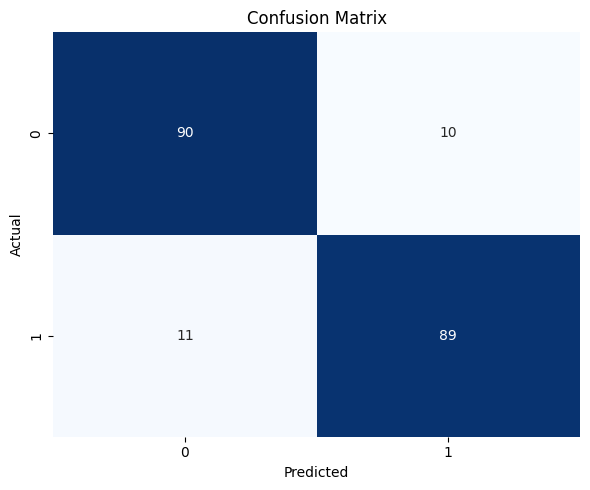

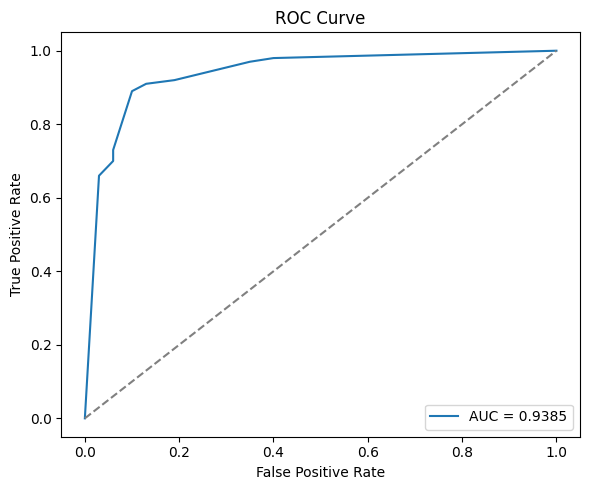

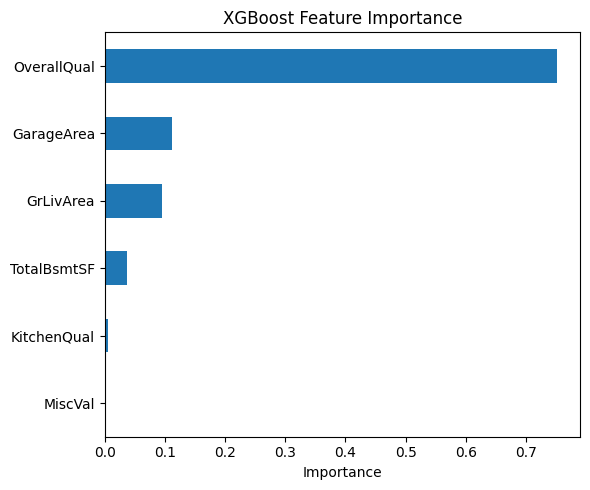

<Figure size 640x480 with 0 Axes>

OverallQual   0.7522
GarageArea    0.1108
GrLivArea     0.0945
TotalBsmtSF   0.0372
KitchenQual   0.0053
MiscVal       0.0000
dtype: float32

In [317]:
# 1) Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2) ROC curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 3) Feature importance
plt.figure(figsize=(6, 5))
feature_importance = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=True)
feature_importance.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

feature_importance.sort_values(ascending=False)

### Brief summary
The XGBoost model predicts the binarized SalePrice strong performance in terms of Accuracy, F1, and AUC

Based on the feature-importance plot, variables linked with quality and area contribute most to the predictions, whereas additional field like MiscVal is not important

Confusion matrix confirms high accuracy, recall and precision

AUC close to 1 means the model almost perfectly ranks positive cases higher than negative ones. It shows high True Positive Rate with low False Positive Rate

In [318]:
# choosing samples closer to the decision boundary, because for confident prediction it was not possible to change prediction using only single feature
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
boundary_indices = np.argsort(np.abs(y_test_pred_proba - 0.5))[2:5]
X_test_sample = X_test.iloc[boundary_indices]
X_test_sample

,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal
Id,,,,,,
1384,0.4444,0.2038,0.4062,0.1336,0.6667,0.0000
842,0.4444,0.2270,0.4838,0.1064,0.6667,0.0000
599,0.4444,0.2474,0.4379,0.2340,0.6667,0.0000


In [319]:
y_pred = xgb_model.predict(X_test_sample)
y_proba = xgb_model.predict_proba(X_test_sample)[:, 1]
print(y_pred)
print(y_proba)

[0 0 0]
[0.4995 0.4995 0.4995]


All three cases are close to the decision boundary (≈0.5) because their feature values are very similar and balanced: moderate OverallQual (~0.44) and KitchenQual (~0.67) don’t strongly push toward class 1, while GrLivArea, GarageArea, and TotalBsmtSF vary slightly but not enough to create a decisive shift

/home/csuchorski/put_sem6/DA/.venv/lib64/python3.14/site-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

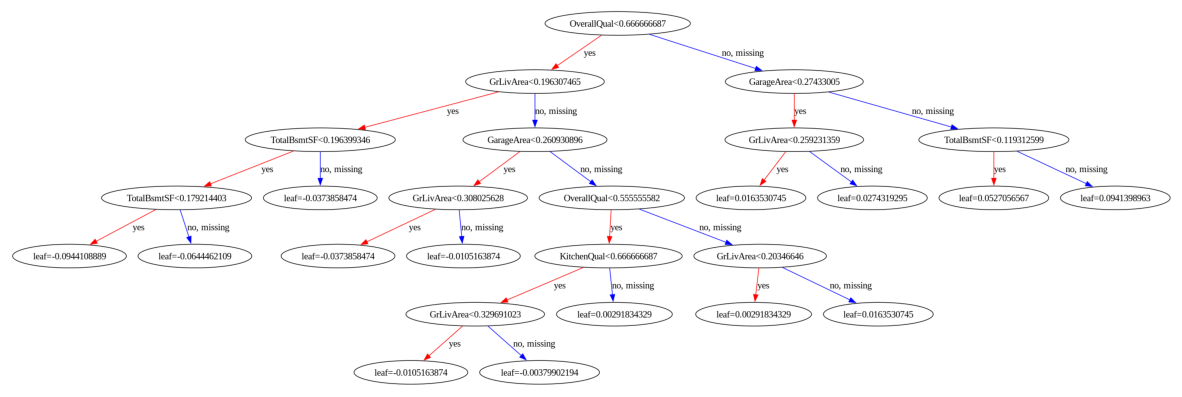

In [320]:
from xgboost import plot_tree


booster = xgb_model.get_booster()
fig, ax = plt.subplots(figsize=(15, 15))

plot_tree(xgb_model, ax=ax, num_trees=0)

Id 1384: OverallQual 0.4444 -> >=0.6667 (minimum +0.2223)
Id 842: OverallQual 0.4444 -> >=0.6667 (minimum +0.2223)
Id 599: OverallQual 0.4444 -> >=0.6667 (minimum +0.2223)
After that change, each sample follows the right branch with their current GarageArea and TotalBsmtSF, they land in the class 1 region shown on the right side.

In [321]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

for i in range(len(X_test_sample)):
    print(f"\nSample {i}")
    print("Prediction:", y_pred[i])
    print("Probability:", y_proba[i])

    sv = shap_values[i]
    contributions = list(zip(X_test_sample.columns, sv))

    # sort by influence
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    print("Most influencing features:")
    for f, v in contributions[:5]:
        print(f, v)


Sample 0
Prediction: 0
Probability: 0.4994796
Most influencing features:
OverallQual -0.05013685
GrLivArea 0.04514687
GarageArea 0.006809153
KitchenQual 0.00442242
TotalBsmtSF -0.0011281515

Sample 1
Prediction: 0
Probability: 0.4994796
Most influencing features:
GrLivArea 0.04514687
OverallQual -0.042540576
TotalBsmtSF -0.008577682
GarageArea 0.006662407
KitchenQual 0.00442242

Sample 2
Prediction: 0
Probability: 0.4994796
Most influencing features:
OverallQual -0.04791762
GrLivArea 0.029552883
TotalBsmtSF 0.0122466
GarageArea 0.006809153
KitchenQual 0.00442242


Sample 0: The most important features are OverallQual (negative impact) and GrLivArea (positive impact); they matter most because they have the largest absolute SHAP values, meaning they influence the prediction more than the other features.

Sample 1: GrLivArea (positive) and OverallQual (negative) are again the most important, as they show the strongest contributions compared to smaller effects from the rest.

Sample 2: OverallQual (negative) and GrLivArea (positive) dominate, since their SHAP values are largest and thus drive the prediction more than the other features.

Sampling

In [322]:
import numpy as np


def empirical_sampling(model, x_row, eps_values):
    base = model.predict_proba([x_row])[0, 1]

    results = []
    sv = shap_values[i]
    contributions = list(zip(X_test_sample.columns, sv))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    feature = contributions[0][0]
    print(feature)
    idx = X_test_sample.columns.get_loc(feature)

    for eps in eps_values:
        # all features are gain type
        if base > 0.5:
            sign = -1
        else:
            sign = 1

        x_new = x_row.copy().astype(float)
        x_new[idx] += eps * sign

        p = model.predict_proba([x_new])[0, 1]
        pred = int(p > 0.5)

        results.append((round(eps, 4), round(p, 4), pred))

        if pred != int(base > 0.5):
            break
    return results

In [323]:
for i in range(len(X_test_sample)):
    print(i)
    x = X_test_sample.iloc[i].values

    eps_values = [
        0,
        0.001,
        0.01,
        0.05,
        0.1,
        0.2,
        0.5,
        1,
        2,
        5,
        10,
        100,
        1000,
        10000,
        999999999999,
    ]

    results = empirical_sampling(xgb_model, x, eps_values)

    for r in results:
        print(r)

0
OverallQual
(0, np.float32(0.4995), 0)
(0.001, np.float32(0.4995), 0)
(0.01, np.float32(0.4995), 0)
(0.05, np.float32(0.4995), 0)
(0.1, np.float32(0.4995), 0)
(0.2, np.float32(0.5028), 1)
1
GrLivArea
(0, np.float32(0.4995), 0)
(0.001, np.float32(0.4995), 0)
(0.01, np.float32(0.4995), 0)
(0.05, np.float32(0.4995), 0)
(0.1, np.float32(0.4995), 0)
(0.2, np.float32(0.4995), 0)
(0.5, np.float32(0.4995), 0)
(1, np.float32(0.4995), 0)
(2, np.float32(0.4995), 0)
(5, np.float32(0.4995), 0)
(10, np.float32(0.4995), 0)
(100, np.float32(0.4995), 0)
(1000, np.float32(0.4995), 0)
(10000, np.float32(0.4995), 0)
(999999999999, np.float32(0.4995), 0)
2
OverallQual
(0, np.float32(0.4995), 0)
(0.001, np.float32(0.4995), 0)
(0.01, np.float32(0.4995), 0)
(0.05, np.float32(0.4995), 0)
(0.1, np.float32(0.4995), 0)
(0.2, np.float32(0.5028), 1)


empirical results are matching the analytics, eg. after adding 0.2 to Overall quality for sample 0 and 2 we have flipped  the class, changing GrLivArea doesn't influence class, even though it was the most influencing feature 

# Interpretation

user preferences: Higher overall quality - strongest driver
Larger living space & garage,
user does not care about miscVal

/tmp/ipykernel_18022/2880062376.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


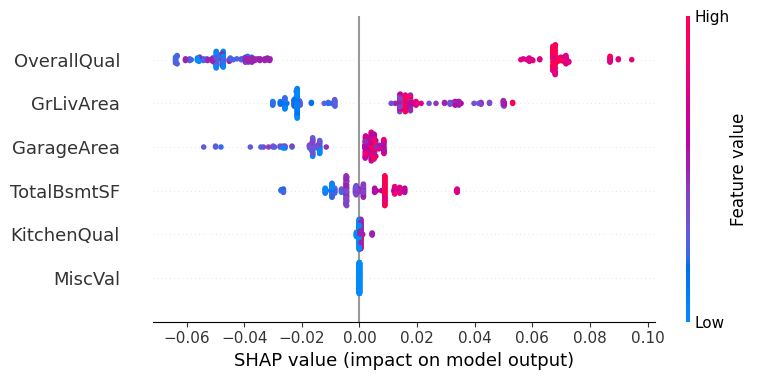

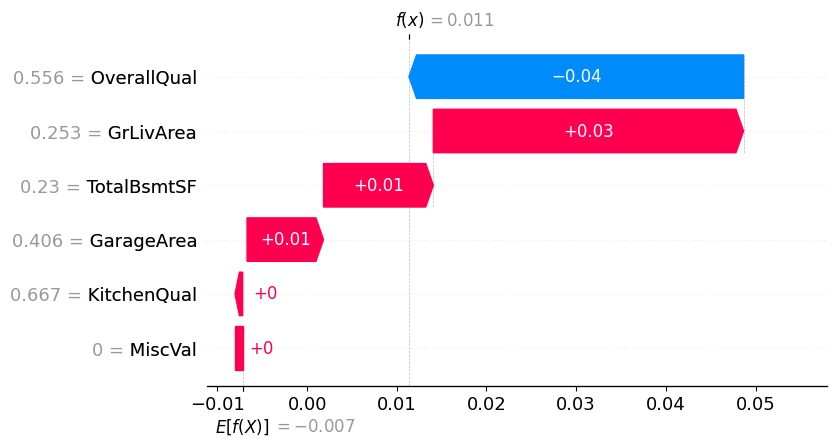

In [324]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

shap.waterfall_plot(shap_values[0])

Every feature is of a gain type and is monotonic

- GrLivArea: Strong positive effect; larger homes increase predictions.
- GarageArea: moderate positive impact; bigger garages generally raise predictions.
- OverallQual: Very important; higher quality sharply increases predictions.
- TotalBsmtSF: moderate positive effect; larger basements increase predictions.
- KitchenQual: minimal impact.
- MiscVal: Minimal impact; largely irrelevant to predictions.

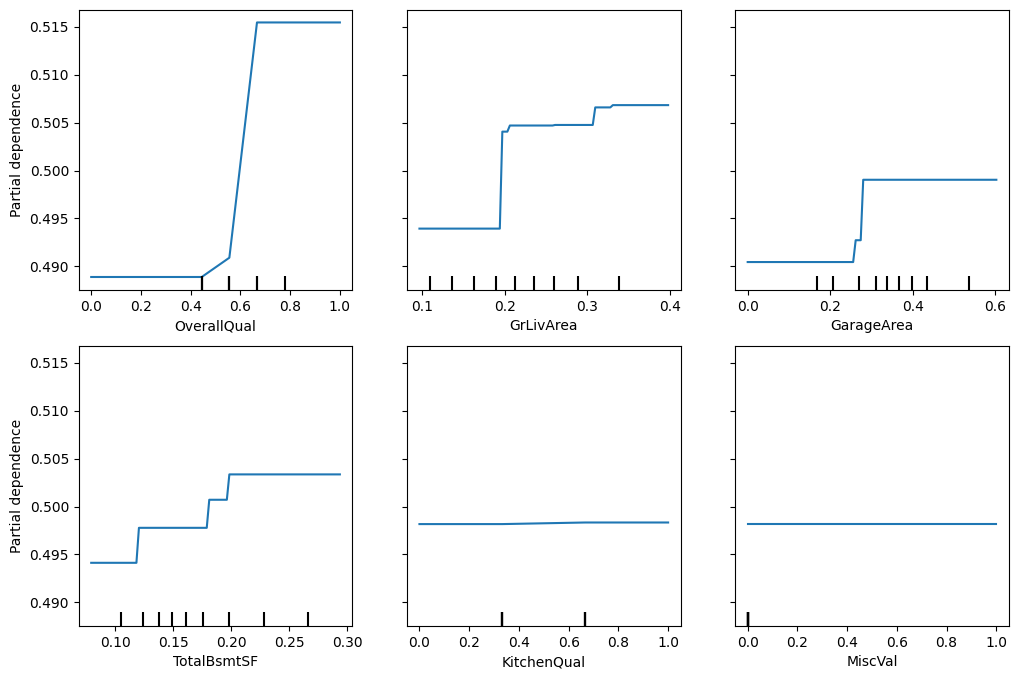

In [325]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(xgb_model, X_train, [0, 1, 2, 3, 4, 5], ax=ax)

plt.show()

partial dependency plot show how each feature affects the model's prediction on average, while holding other features constant.

- OverallQual: strongest positive effect (very important)
- GrLivArea, GarageArea: increase prediction, then level off
- KitchenQual: no impact
- TotalBsmtSF: step-wise positive impact
- MiscVal: no impact

preference tresholds: 

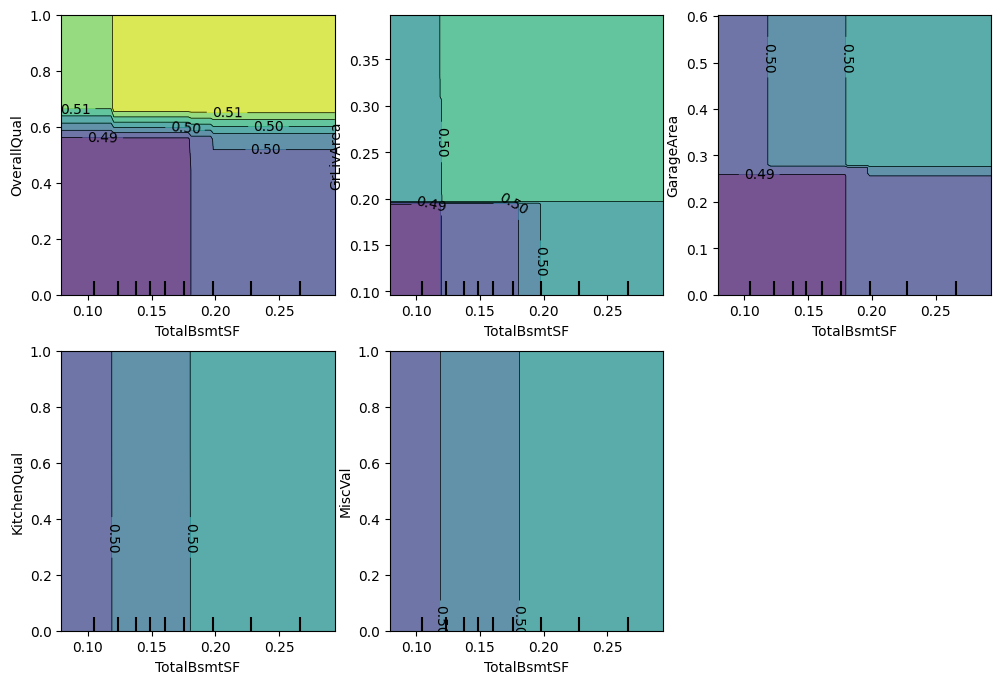

In [326]:
fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_train,
    [(3, i) for i in range(X_train.shape[1]) if i != 3],
    ax=ax,
)

OverallQual (top-left) has the strongest interaction: higher OverallQual + moderate/higher TotalBsmtSF pushes prediction upward (yellow region).
GrLivArea and GarageArea add only mild shifts around threshold-like boundaries.
KitchenQual and MiscVal panels are almost purely vertical bands, suggesting those features have little additional effect beyond TotalBsmtSF here.

# ANN-UTA


In [327]:
import sys
from pathlib import Path

import torch

_ROOT = Path.cwd()
_UTA_DIR = _ROOT / "UTA"
if str(_UTA_DIR) not in sys.path:
    sys.path.insert(0, str(_UTA_DIR))

from norm_layer import NormLayer
from uta import Uta

UTA_CHECKPOINT = _UTA_DIR / "uta.pt2"
NUM_HIDDEN = 30

feature_cols_uta = [c for c in df.columns if c != "SalePrice"]
num_criteria_uta = len(feature_cols_uta)

uta_model = Uta(num_criteria_uta, NUM_HIDDEN)
uta_model = NormLayer(uta_model, num_criteria_uta)

ckpt = torch.load(UTA_CHECKPOINT, map_location="cpu")
uta_model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [328]:
_, X_uta_test, _, y_uta_test = train_test_split(
    df[feature_cols_uta],
    df["SalePrice"],
    test_size=0.2,
    random_state=1234,
)
X_uta_test = X_uta_test.head(100)
y_uta_test = y_uta_test.head(100)

In [329]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

uta_model.eval()
X_uta = X_uta_test.values.astype("float32").reshape(-1, 1, num_criteria_uta)
X_uta_t = torch.from_numpy(X_uta)

with torch.no_grad():
    uta_scores = uta_model(X_uta_t).numpy()

uta_pred = (uta_scores > 0).astype(int)

print("UTA test accuracy:", round(accuracy_score(y_uta_test, uta_pred), 4))
print("UTA test AUC:", round(roc_auc_score(y_uta_test, uta_scores), 4))
print("UTA test F1:", round(f1_score(y_uta_test, uta_pred), 4))

UTA test accuracy: 0.86
UTA test AUC: 0.9612
UTA test F1: 0.8542


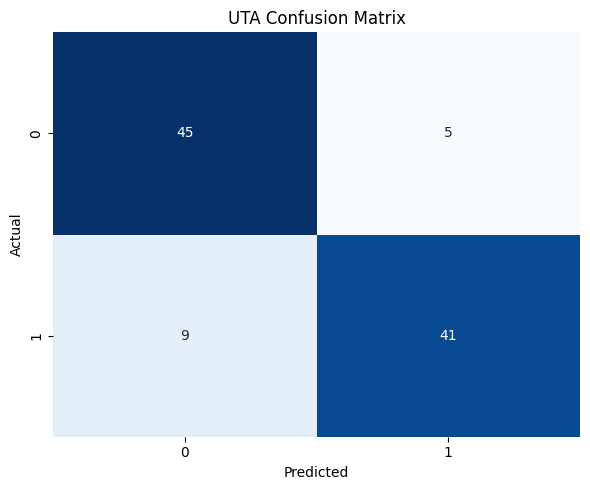

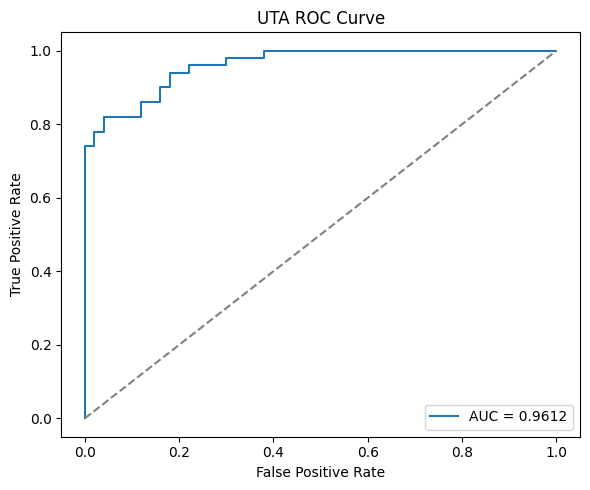

In [330]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_uta_test, uta_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("UTA Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_uta_test, uta_scores)
uta_auc = roc_auc_score(y_uta_test, uta_scores)
plt.plot(fpr, tpr, label=f"AUC = {uta_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("UTA ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [331]:
import numpy as np
import shap


# GradientExplainer expects a 2D model output (batch, 1); UTA returns (batch,).
class _UtaShapWrapper(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super().__init__()
        self.model = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).view(-1, 1)


uta_for_shap = _UtaShapWrapper(uta_model).eval()

explainer_uta = shap.GradientExplainer(uta_for_shap, X_uta_t)

shap_values_uta = explainer_uta.shap_values(X_uta_t)
shap_values_uta = np.asarray(shap_values_uta)
X_uta_sample = X_uta_t[:3]

if shap_values_uta.ndim == 4:
    shap_values_uta = shap_values_uta[:, 0, :, 0]

with torch.no_grad():
    uta_scores_sample = uta_for_shap(X_uta_t).numpy().ravel()

uta_pred_sample = (uta_scores_sample > 0).astype(int)

for i in range(len(X_uta_sample)):
    print(f"\nSample {i}")
    print("Prediction (score > 0):", uta_pred_sample[i])
    print("Score (utility - threshold):", uta_scores_sample[i])

    sv = shap_values_uta[i]
    contributions = list(zip(X_uta_test.columns, sv))

    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    print("Most influencing features:")
    for f, v in contributions[:5]:
        print(f, round(v, 4))


Sample 0
Prediction (score > 0): 0
Score (utility - threshold): -0.038960457
Most influencing features:
KitchenQual -0.0314
GrLivArea 0.0219
GarageArea -0.0219
OverallQual 0.0077
TotalBsmtSF 0.0062

Sample 1
Prediction (score > 0): 1
Score (utility - threshold): 0.10751757
Most influencing features:
KitchenQual 0.0425
OverallQual 0.0323
GarageArea 0.0211
TotalBsmtSF 0.0141
GrLivArea -0.0104

Sample 2
Prediction (score > 0): 0
Score (utility - threshold): -0.1312829
Most influencing features:
GarageArea -0.0777
KitchenQual -0.0262
OverallQual -0.0243
GrLivArea 0.0179
TotalBsmtSF -0.0006


Sample 0 -> 0: total score is negative (-0.039), mainly due to KitchenQual and GarageArea negatives.
Sample 1 -> 1: total score is positive (+0.108), driven by strong positives from KitchenQual, OverallQual, and GarageArea.
Sample 2 -> 0: total score is strongly negative (-0.131), mostly because of a large negative GarageArea effect.

In [332]:
import numpy as np
import torch


def predict_uta_score_and_class(model, x_row):
    x_t = torch.tensor(x_row, dtype=torch.float32).view(1, 1, -1)
    with torch.no_grad():
        score = float(model(x_t).view(-1).item())
    pred = int(score > 0)
    return score, pred


def empirical_sampling_uta(model, x_row, feature_names, sv, eps_values):
    base_score, base_pred = predict_uta_score_and_class(model, x_row)

    contributions = list(zip(feature_names, sv))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    feature, feature_shap = contributions[0]
    idx = feature_names.get_loc(feature)

    direction = -1 if base_pred == 1 else 1

    results = []
    for eps in eps_values:
        x_new = x_row.copy().astype(np.float32)
        x_new[idx] = np.clip(x_new[idx] + eps * direction, 0.0, 1.0)

        score, pred = predict_uta_score_and_class(model, x_new)
        results.append((eps, score, pred))

        if pred != base_pred:
            break

    return {
        "feature": feature,
        "feature_shap": float(feature_shap),
        "base_score": base_score,
        "base_pred": base_pred,
        "direction": direction,
        "results": results,
    }


eps_values = [0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]

for i in range(len(X_uta_sample)):
    print(f"\nSample {i}")
    x = X_uta_test.iloc[i].values.astype(np.float32)

    out = empirical_sampling_uta(
        uta_model,
        x,
        X_uta_test.columns,
        shap_values_uta[i],
        eps_values,
    )

    print("Base class (score > 0):", out["base_pred"])
    print("Base score:", round(out["base_score"], 4))
    print("Most influential feature:", out["feature"])
    print("SHAP contribution of that feature:", round(out["feature_shap"], 4))

    for eps, score, pred in out["results"]:
        print((eps, round(score, 4), pred))


Sample 0
Base class (score > 0): 0
Base score: -0.039
Most influential feature: KitchenQual
SHAP contribution of that feature: -0.0314
(0, -0.039, 0)
(0.001, -0.0386, 0)
(0.01, -0.035, 0)
(0.05, -0.0191, 0)
(0.1, 0.0006, 1)

Sample 1
Base class (score > 0): 1
Base score: 0.1075
Most influential feature: KitchenQual
SHAP contribution of that feature: 0.0425
(0, 0.1075, 1)
(0.001, 0.1075, 1)
(0.01, 0.1073, 1)
(0.05, 0.1052, 1)
(0.1, 0.101, 1)
(0.2, 0.0811, 1)
(0.5, -0.0304, 0)

Sample 2
Base class (score > 0): 0
Base score: -0.1313
Most influential feature: GarageArea
SHAP contribution of that feature: -0.0777
(0, -0.1313, 0)
(0.001, -0.1313, 0)
(0.01, -0.1312, 0)
(0.05, -0.1301, 0)
(0.1, -0.1162, 0)
(0.2, -0.0791, 0)
(0.5, -0.014, 0)
(1, 0.063, 1)


In [333]:
X_uta_test

,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,KitchenQual,MiscVal
Id,,,,,,
111,0.5556,0.2865,0.2292,0.1627,0.3333,0.0000
978,0.6667,0.1709,0.4013,0.2031,0.6667,0.0000
1451,0.4444,0.2747,0.0000,0.1466,0.3333,0.0000
965,0.6667,0.2939,0.3597,0.1337,0.6667,0.0000
136,0.6667,0.2540,0.3738,0.2134,0.3333,0.0000
...,...,...,...,...,...,...
365,0.5556,0.2336,0.3992,0.1303,0.3333,0.0000
967,0.4444,0.1835,0.1805,0.1191,0.3333,0.0000
1247,0.6667,0.2297,0.4337,0.1237,0.6667,0.0000


based on the plots of marginal functions presented in ANN-UTADIS we can say that u1 (OverallQual) has the largest cotribution (up to 0.25), u3 (GarageArea) and u5 (KitchenQual) have strong contribution and u6  (MiscVal) minimal contribution, because it has low weight

The user seems to prioritize getting acceptable performance quickly on key criteria (g1, g3, g5), then values additional gains less

/tmp/ipykernel_18022/2412397895.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_uta, X_uta_test)


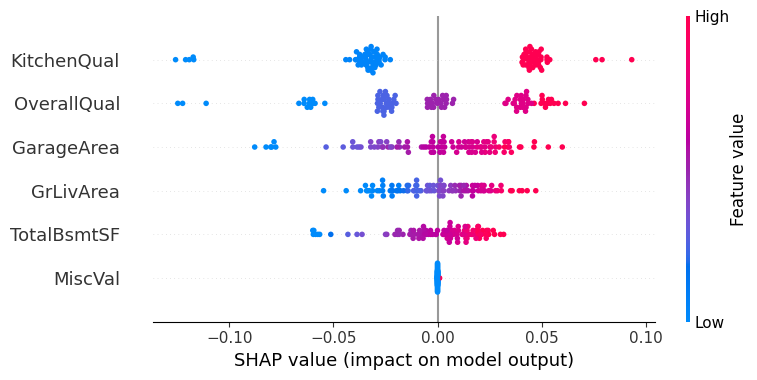

In [334]:
shap.summary_plot(shap_values_uta, X_uta_test)

Every feature is of a gain type and is monotonic

plot indicates that the model's predictions are driven mostly by KitchenQual and OverallQual (high values increase predictions, low values decrease them), with GarageArea, GrLivArea, and TotalBsmtSF showing similar but weaker positive at high value effects, while MiscVal has almost no impact.


Uta uses additive function, so there is no dependency between marginal functions

# Neural net


In [335]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler


class SmallNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

In [336]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [337]:
nn_model = SmallNetwork(input_dim=6)

criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

epochs = 200

for epoch in range(epochs):
    nn_model.train()

    optimizer.zero_grad()
    outputs = nn_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.7037
Epoch 10, Loss: 0.6798
Epoch 20, Loss: 0.6556
Epoch 30, Loss: 0.6286
Epoch 40, Loss: 0.5933
Epoch 50, Loss: 0.5446
Epoch 60, Loss: 0.4873
Epoch 70, Loss: 0.4307
Epoch 80, Loss: 0.3829
Epoch 90, Loss: 0.3471
Epoch 100, Loss: 0.3222
Epoch 110, Loss: 0.3059
Epoch 120, Loss: 0.2951
Epoch 130, Loss: 0.2876
Epoch 140, Loss: 0.2822
Epoch 150, Loss: 0.2779
Epoch 160, Loss: 0.2741
Epoch 170, Loss: 0.2708
Epoch 180, Loss: 0.2677
Epoch 190, Loss: 0.2646


In [338]:
nn_model.eval()

with torch.no_grad():
    y_proba_nn = nn_model(X_test_t).numpy().flatten()

y_pred_nn = (y_proba_nn > 0.5).astype(int)

accuracy = round(accuracy_score(y_test, y_pred_nn), 4)
f1 = round(f1_score(y_test, y_pred_nn), 4)
auc = round(roc_auc_score(y_test, y_proba_nn), 4)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

Accuracy: 0.8950
F1 score: 0.8976
AUC: 0.9674


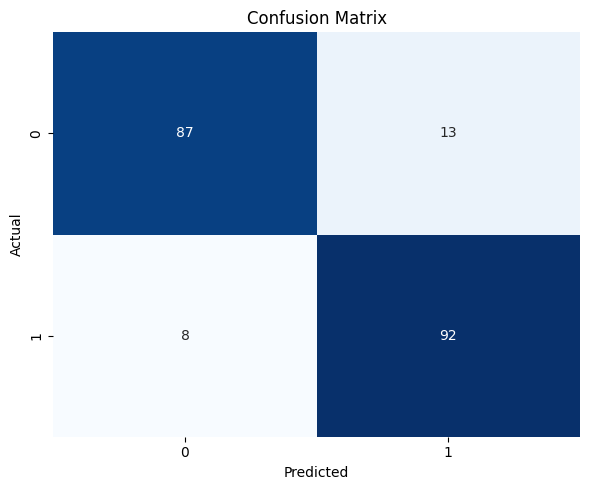

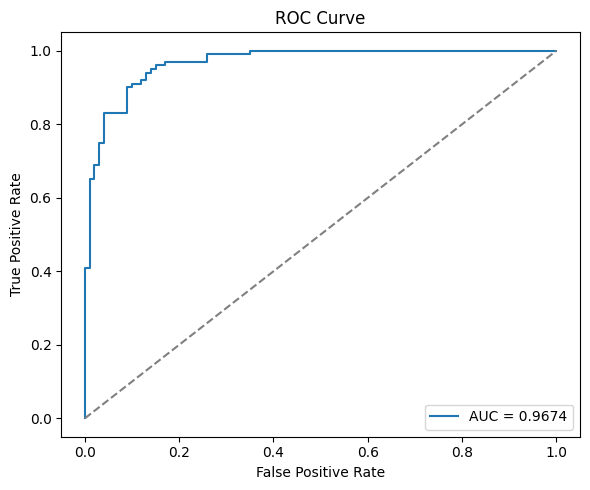

<Figure size 640x480 with 0 Axes>

OverallQual   0.7522
GarageArea    0.1108
GrLivArea     0.0945
TotalBsmtSF   0.0372
KitchenQual   0.0053
MiscVal       0.0000
dtype: float32

In [339]:
# 1) Confusion matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2) ROC curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_proba_nn)
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

feature_importance.sort_values(ascending=False)

/tmp/ipykernel_18022/4187060811.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_nn, X_test_t, feature_names=X_test.columns.tolist())


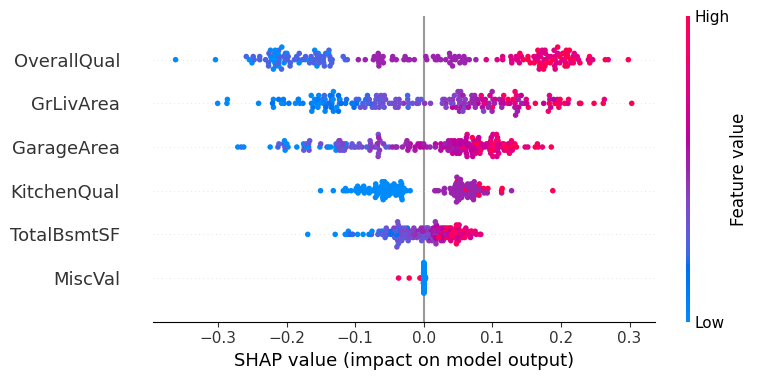

/tmp/ipykernel_18022/4187060811.py:26: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


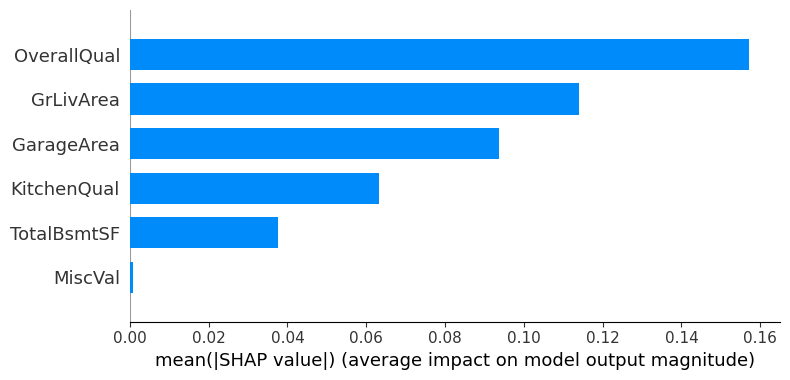


Sample 0
Prediction (proba > 0.5): 1


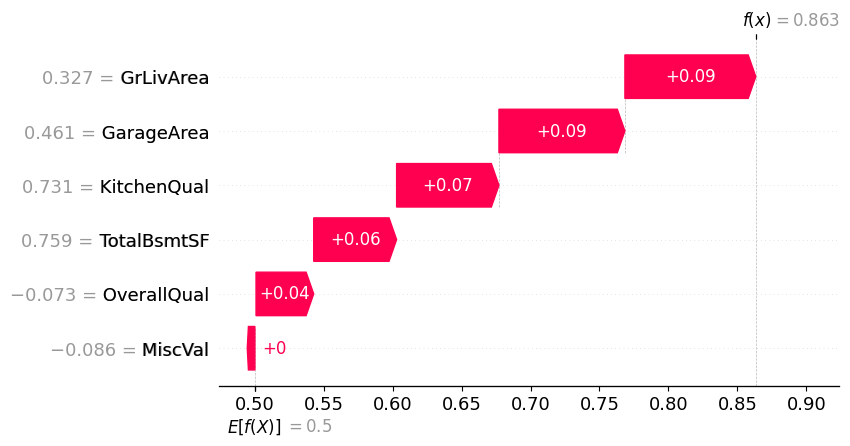


Sample 1
Prediction (proba > 0.5): 1


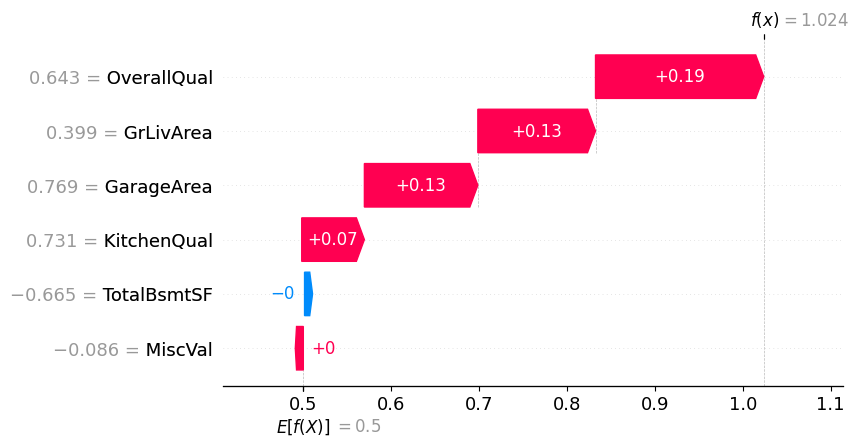


Sample 2
Prediction (proba > 0.5): 0


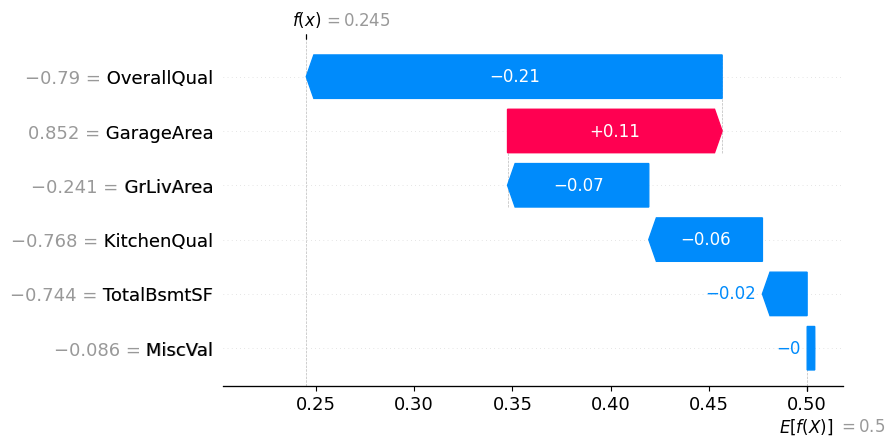

In [340]:
import numpy as np
import shap


class _NNShapWrapper(torch.nn.Module):
    def __init__(self, model: torch.nn.Module):
        super().__init__()
        self.model = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).view(-1, 1)


nn_for_shap = _NNShapWrapper(nn_model).eval()
explainer_nn = shap.GradientExplainer(nn_for_shap, X_test_t)
shap_values_nn = explainer_nn.shap_values(X_test_t)
shap_values_nn = np.asarray(shap_values_nn)

shap_values_nn = shap_values_nn[:, :, 0]

with torch.no_grad():
    nn_scores_sample = nn_model(X_test_t).numpy().ravel()
nn_pred_sample = (nn_scores_sample > 0.5).astype(int)

shap.summary_plot(shap_values_nn, X_test_t, feature_names=X_test.columns.tolist())
shap.summary_plot(
    shap_values_nn, X_test_t, feature_names=X_test.columns.tolist(), plot_type="bar"
)

for i in range(3):
    print(f"\nSample {i}")
    print("Prediction (proba > 0.5):", nn_pred_sample[i])

    sv = shap_values_nn[i]

    explanation = shap.Explanation(
        values=sv,
        base_values=0.5,
        data=X_test_np[i],
        feature_names=X_test.columns.tolist(),
    )
    shap.plots.waterfall(explanation)

In [346]:
eps_values = [0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]

for i in range(3):
    print(f"\nSample {i}")
    x = X_test_scaled[i].astype(np.float32)

    out = empirical_sampling_uta(
        nn_model,
        x,
        X_test.columns,
        shap_values_nn[i],
        eps_values,
    )

    print("Base class (score > 0):", out["base_pred"])
    print("Base score:", round(out["base_score"], 4))
    print("Most influential feature:", out["feature"])
    print("SHAP contribution of that feature:", round(out["feature_shap"], 4))

    for eps, score, pred in out["results"]:
        print((eps, round(score, 4), pred))


Sample 0
Base class (score > 0): 1
Base score: 0.8791
Most influential feature: GrLivArea
SHAP contribution of that feature: 0.095
(0, 0.8791, 1)
(0.001, 0.879, 1)
(0.01, 0.8785, 1)
(0.05, 0.876, 1)
(0.1, 0.8729, 1)
(0.2, 0.8655, 1)
(0.5, 0.8552, 1)
(1, 0.8552, 1)
(2, 0.8552, 1)
(5, 0.8552, 1)
(10, 0.8552, 1)

Sample 1
Base class (score > 0): 1
Base score: 0.9476
Most influential feature: OverallQual
SHAP contribution of that feature: 0.1914
(0, 0.9476, 1)
(0.001, 0.9476, 1)
(0.01, 0.9471, 1)
(0.05, 0.9447, 1)
(0.1, 0.9415, 1)
(0.2, 0.9348, 1)
(0.5, 0.9121, 1)
(1, 0.8976, 1)
(2, 0.8976, 1)
(5, 0.8976, 1)
(10, 0.8976, 1)

Sample 2
Base class (score > 0): 1
Base score: 0.2295
Most influential feature: OverallQual
SHAP contribution of that feature: -0.2117
(0, 0.5389, 1)
(0.001, 0.5389, 1)
(0.01, 0.5389, 1)
(0.05, 0.5389, 1)
(0.1, 0.5389, 1)
(0.2, 0.5389, 1)
(0.5, 0.5389, 1)
(1, 0.5389, 1)
(2, 0.5389, 1)
(5, 0.5389, 1)
(10, 0.5389, 1)


In [ ]:
with torch.no_grad():
    all_scores = nn_model(X_test_t).numpy().ravel()

distances = np.abs(all_scores - 0.5)
boundary_indices = np.argsort(distances)[12:15]

print("Samples closest to decision boundary:")
for idx in boundary_indices:
    print(f"  Sample {idx} | score: {all_scores[idx]:.4f}")

eps_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

for idx in boundary_indices:
    print(f"\n{'='*50}")
    print(
        f"Sample {idx} | base score: {all_scores[idx]:.4f} | base pred: {int(all_scores[idx] > 0.5)}"
    )

    top_feat_idx = np.abs(shap_values_nn[idx]).argmax()
    print(f"Top feature: {X_test.columns[top_feat_idx]}")

    x_original = scaler.inverse_transform(X_test_scaled[idx].reshape(1, -1))

    for eps in eps_values:
        # perturb in both directions
        flipped = False
        for direction, sign in [("+", 1), ("-", -1)]:
            x_perturbed = x_original.copy()
            x_perturbed[0, top_feat_idx] += sign * eps

            x_scaled = scaler.transform(x_perturbed)
            x_t = torch.tensor(x_scaled, dtype=torch.float32)

            with torch.no_grad():
                new_score = nn_model(x_t).item()

            flipped = int(new_score > 0.5) != int(all_scores[idx] > 0.5)
            if flipped:
                print(
                    f"  eps={direction}{eps} | score={new_score:.4f} | pred={int(new_score > 0.5)}"
                )
                break
        if flipped:
            break

Samples closest to decision boundary:
  Sample 88 | score: 0.4310
  Sample 154 | score: 0.5766
  Sample 48 | score: 0.5780

Sample 88 | base score: 0.4310 | base pred: 0
Top feature: KitchenQual
  eps=+0.1 | score=0.5634 | pred=1

Sample 154 | base score: 0.5766 | base pred: 1
Top feature: GrLivArea
  eps=-0.05 | score=0.3451 | pred=0

Sample 48 | base score: 0.5780 | base pred: 1
Top feature: GrLivArea
  eps=-0.05 | score=0.3386 | pred=0


/home/csuchorski/put_sem6/DA/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/csuchorski/put_sem6/DA/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/csuchorski/put_sem6/DA/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/csuchorski/put_sem6/DA/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/csuchorski/put_sem6/DA/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid f

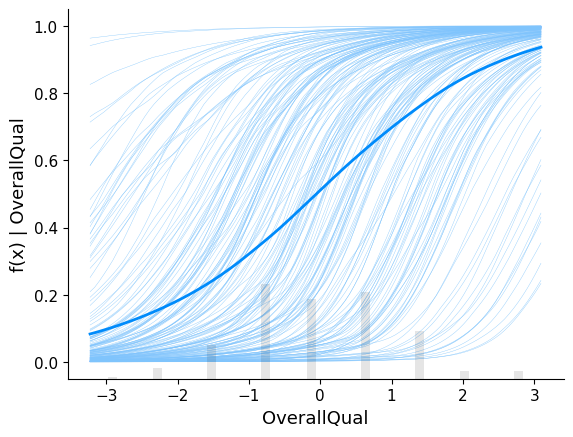

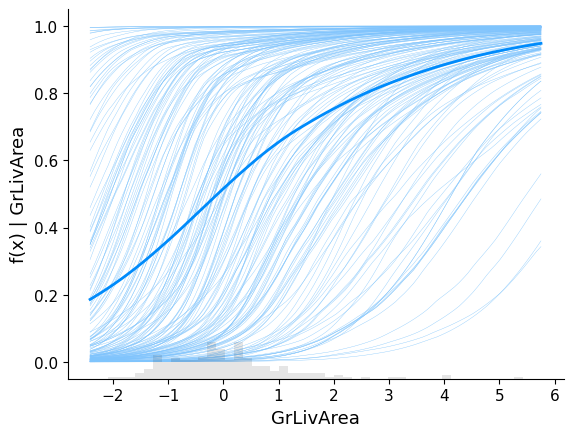

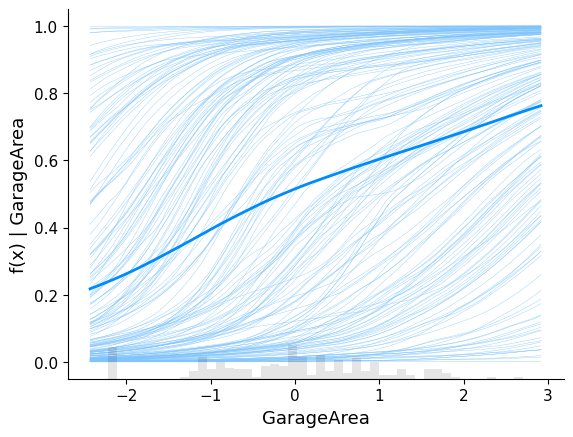

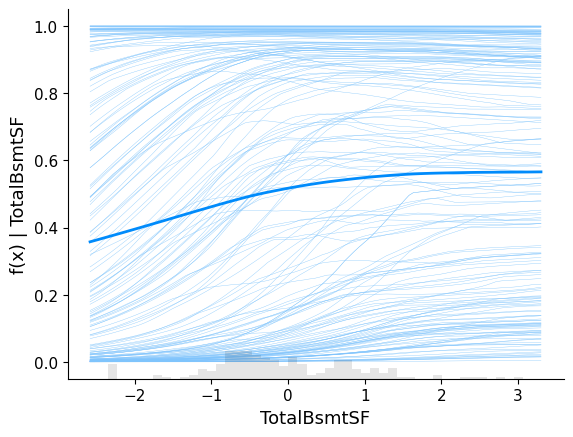

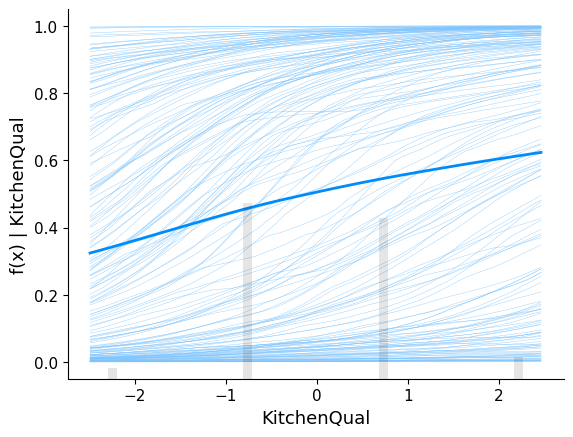

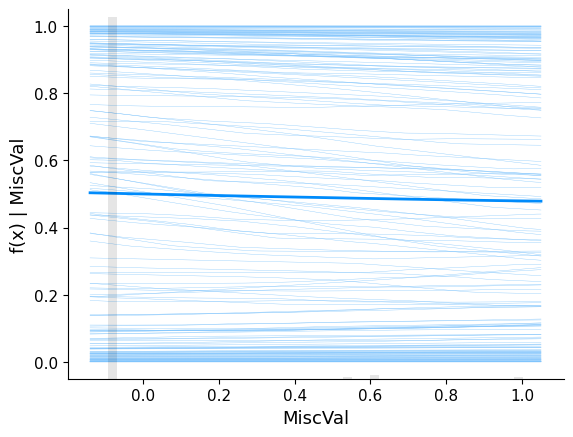

In [385]:
def model_predict(X):
    x_t = torch.tensor(X.astype(np.float32))
    with torch.no_grad():
        return nn_model(x_t).numpy().ravel()


for i, name in enumerate(X_test.columns):
    shap.partial_dependence_plot(
        i,
        model_predict,
        X_test_scaled,
        feature_names=X_test.columns.tolist(),
    )